In [ ]:
# 1. 이진분류(Binary Classification) 실습
# - 이진분류 모델 학습
# - 학습 결과 저장
# - 저장된 모델/ 스케일러/ 학습 이력 불러오기
# - 신규 데이터 예측
# - 학습결과 및 예측결과 시각화

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_breast_cancer   # 유방암 진단 데이터 셋 읽어오기
import joblib                                     # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                           # 딥러닝 프레임워크

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout             # 레이어 구성 및 드랍아웃(블랙박스의 특정 뉴런 제거시 성능 향상 이유 X) 적용 라이브러리
from tensorflow.keras.callbacks import EarlyStopping           # 학습 조기종료 콜백 라이브러리

np.random.seed(42)
tf.random.set_seed(42)


I0000 00:00:1787271876.462634   12463 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787271876.463451   12463 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787271876.806233   12463 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787271878.597404   12463 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_E

In [ ]:
# 1. 데이터 읽어오기

data = load_breast_cancer()
X = data.data         # 입력 X data
y = data.target       # 타겟 레이블 y 데이터 (예측하고자 하는 데이터)

feature_names = data.feature_names    # 특성 이름
df = pd.DataFrame(X, columns=feature_names)       # 데이터 확인을 위해 데이터프레임으로 변환

df['target'] = y

print('전체 데이터 shape: ', df.shape)


전체 데이터 shape:  (569, 31)


array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [10]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [11]:
# 2. 학습용 / 테스트용 데이터 분할
X_train, X_test, y_trian, y_test = train_test_split(
  X, y, test_size= 0.2, random_state=42, stratify=y
)

In [12]:
# 3. 스케일링 (값들을 0~1 값으로 변환하기)
scaler = StandardScaler()                           # 스케일러 객체 생성
X_train_scaled = scaler.fit_transform(X_train)      # 학습 데이터 기준으로  평균과 표준편차를 학습후 반환
X_test_scaled = scaler.transform(X_test)            # 테스트 데이터는 학습 데이터 기준으로 반환

In [ ]:
# 4. 모델 정의
model = Sequential()              # 모델 프레임 생성

# 첫 번째 은닉층 추가
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))         # 과적합 방지를 위해 드롭아웃 20% 적용

# 두 번째 은닉층 추가
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# 출력층
model.add(Dense(1, activation='sigmoid'))     # 이진분류 모델 (0,1) 이기 때문에 Dense 뉴런을 1개만 생성한다.

# 모델 구조 출력
model.summary()

/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1787273414.290769   12463 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787273414.344028   12463 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# 5. 모델 컴파일 설정

model.compile(
  optimizer='adam',                         # 학습은 adam
  loss = 'binary_crossentropy',             # 손실함수는 bianary_crossentropy 적용
  metrics = ['accuracy']                    # 평가지표는 accuracy 사용
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
  monitor='val_loss',                   # val_loss 값이 더이상 줄어들지 않는다면
  patience=10,                          # 
  restore_best_weights=True
)

In [18]:
# 6. 모델 학습
# 모델을 학습하고, history 객체에 학습 과정을 저장
history = model.fit(
  X_train_scaled,               # 입력데이터 X
  y_trian,                      # 정답데이터 y
  validation_split=0.2,           # 검증 20%
  epochs=100,                   # 전체 학습 수 100번
  batch_size=32,                # 한번에 도는 학습 1회 사이클 32번
  callbacks=[early_stop]        # 조기종료 콜백 정의
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7692 - loss: 0.5696 - val_accuracy: 0.9231 - val_loss: 0.4039
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9258 - loss: 0.3712 - val_accuracy: 0.9451 - val_loss: 0.2728
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9341 - loss: 0.2494 - val_accuracy: 0.9560 - val_loss: 0.1918
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9396 - loss: 0.1908 - val_accuracy: 0.9560 - val_loss: 0.1452
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9505 - loss: 0.1525 - val_accuracy: 0.9560 - val_loss: 0.1163
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9615 - loss: 0.1281 - val_accuracy: 0.9890 - val_loss: 0.0958
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9725 - loss: 0.1133 - val_accuracy: 0.9890 - val_loss: 0.0800
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9753 - loss: 0.1010 - val_accuracy: 0.9890 - 

In [19]:
# 7. 모델 평가
# 테스트 데이터(20%)에 대한 손실과 정확도를 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도 : ', test_acc)

# 에측확률
y_prob = model.predict(X_test_scaled)

# 확률을 0 또는 1 클래스로 변환
y_pred = (y_prob >= 0.5).astype(int).flatten()

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도: ', acc)
print('confusion_matrix: \n', cm)
print('분류 리포트 : \n', classification_report(y_test, y_pred))
 

테스트 손실:  0.1260843575000763
테스트 정확도 :  0.9649122953414917
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
정확도:  0.9649122807017544
confusion_matrix: 
 [[41  1]
 [ 3 69]]
분류 리포트 : 
               precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [20]:
# 8. 학습결과 저장
# 모델을 파일로 저장
model.save('./model/Binary_Classification.h5')    # 또는 Biinary_Classification.keras

# 스케일러를 파일로 저장
joblib.dump(scaler, './model/Binary_Classification.pkl')

# 학습이력을 데이터 프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv 파일로 저장
history_df.to_csv('./model/Binary_Classification.csv', index=False)

print("이진분류 모델, 스케일러, 학습이력 저장 완료")


이진분류 모델, 스케일러, 학습이력 저장 완료


In [21]:
# 9. 저장된 결과 읽어 오기  (프론트엔드에서 실행되는 로직이라고 이해하면 된다)

# 저장된 모델을 다시 읽어오기
loaded_model = tf.keras.models.load_model('./model/Binary_Classification.h5')

# 저장된 스케일러를 다시 읽어오기
loaded_scaler = joblib.load('./model/Binary_Classification.pkl')


In [22]:
# 10. 신규 데이터 예측

# 학습하지 않은 테스트데이터 중 5개를 신규 데이터로 예측 수행
new_data = X_test[:5]

# 신규 데이터 스케일링 처리
new_data_scaled = loaded_scaler.transform(new_data)

# 신규 데이터 예측 확률 계산
new_prob = loaded_model.predict(new_data_scaled)

# 예측 확률값을 0 or 1로 변환
new_pred = (new_prob >= 0.5).astype(int).flatten()

# 결과 출력
for i in range(len(new_data)):
  print(f"{i + 1}번 샘플 - 예측확률: {new_prob[i][0]:.4f}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1번 샘플 - 예측확률: 0.0000, 예측클래스: 0
2번 샘플 - 예측확률: 1.0000, 예측클래스: 1
3번 샘플 - 예측확률: 0.0000, 예측클래스: 0
4번 샘플 - 예측확률: 0.0395, 예측클래스: 0
5번 샘플 - 예측확률: 0.0000, 예측클래스: 0


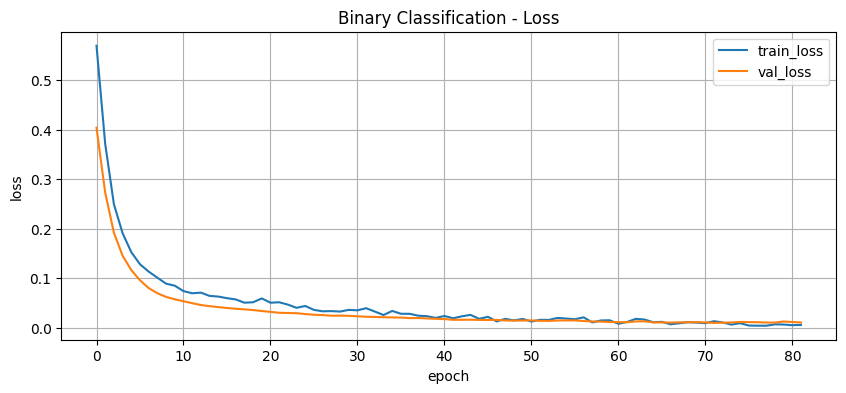

In [23]:
# 11. 시각화 결과 확인

# 학습, Loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Binary Classification - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True) # 그래프 격자 표시
plt.show()

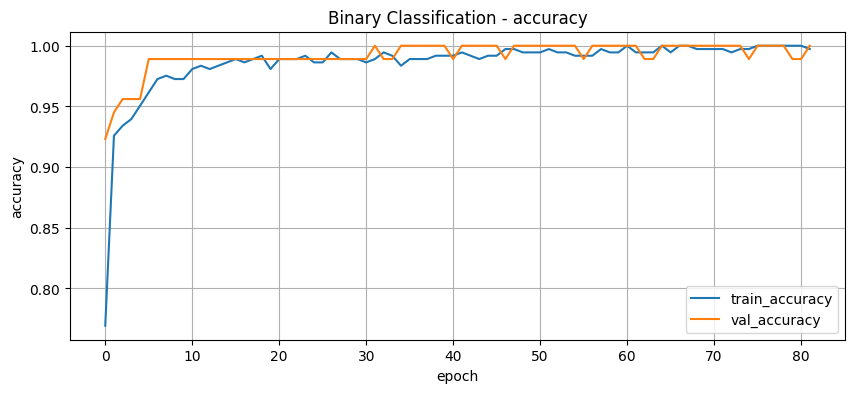

In [ ]:
# 12. 학습, 정확도 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Binary Classification - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True) # 그래프 격자 표시
plt.show()

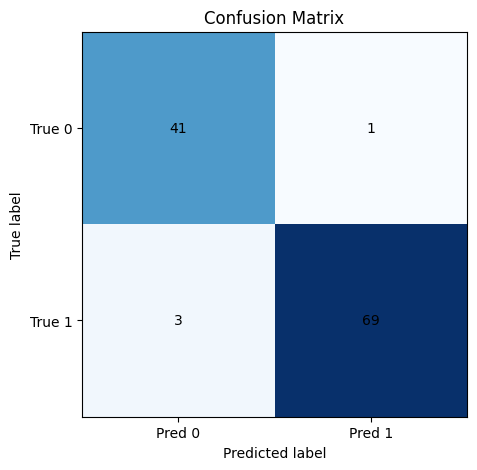

In [ ]:
# 13. confusion matrix A/2t2/
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')

# ×축과 y축 눈금 설정
plt.xticks(([0,1]), ['Pred 0', 'Pred 1'])
plt.yticks(([0,1]), ['True 0', 'True 1'])

# cm 내부에 숫자 표시
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


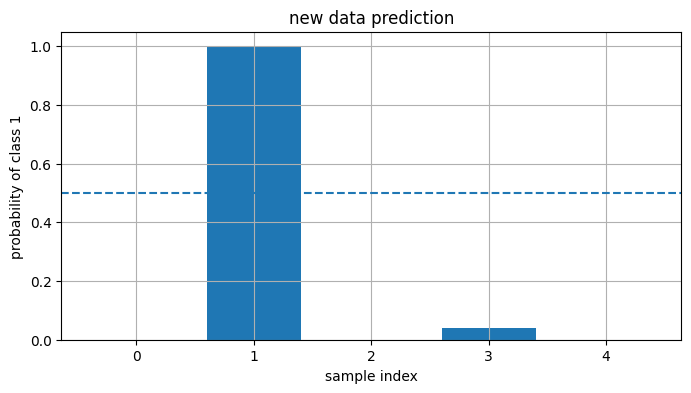

In [28]:
# 신규 데이터 예측 결과 시각화
new_prob_flat = new_prob.flatten()

plt.figure(figsize=(8,4))
plt.bar(range(len(new_prob_flat)), new_prob_flat)

# 기준선 0.5 표시
plt.axhline(0.5, linestyle="--")

plt.title('new data prediction')
plt.xlabel('sample index')
plt.ylabel('probability of class 1')

plt.grid(True)
plt.show()